In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
input_data = pd.read_csv('/home/rachel/Desktop/mm-vae data/multiregion_adbxd_cr/hc_pfc_adbxd_paired_30perc.csv')
input_data

/tmp/ipykernel_30360/298928447.py:1: DtypeWarning: Columns (9712) have mixed types. Specify dtype option on import or set low_memory=False.
  input_data = pd.read_csv('/home/rachel/Desktop/mm-vae data/multiregion_adbxd_cr/hc_pfc_adbxd_paired_30perc.csv')


,0_HC,1_HC,2_HC,3_HC,4_HC,5_HC,6_HC,7_HC,8_HC,9_HC,...,subclass_PFC,cell_type_PFC,SCBID_PFC,MouseID_PFC,Age_PFC,Genotype_PFC,CFM_14_5_snRNA_PFC,14-6-residual_PFC,14-6-Bin_PFC,strain
0,1.032911,0.930804,-0.506429,0.399180,-1.665557,-0.169929,-0.412642,-1.081330,-0.263578,-1.602702,...,334 Microglia NN,Immune,CK19032,1596,14,5,59.16,0.738297,3,124
1,0.652837,0.454148,0.879128,0.030314,-1.489111,0.785163,0.211441,0.474034,-0.107822,-0.063107,...,319 Astro-TE NN,Astrocytes,CK19032,1596,14,5,59.16,0.738297,3,124
2,-0.467760,0.498727,0.423371,-0.196953,-0.577146,-0.254714,0.647625,0.110877,-0.037445,-0.114378,...,030 L6 CT CTX Glut,Glut,CK19032,1596,14,5,59.16,0.738297,3,124
3,0.269693,0.008788,0.001615,0.248190,0.531861,0.174182,-0.656014,0.324071,-0.270391,-0.172469,...,007 L2/3 IT CTX Glut,Glut,CK19032,1596,14,5,59.16,0.738297,3,124
4,0.474351,2.694790,-2.235378,1.500846,-0.067623,0.446731,0.536872,0.355713,-0.701760,-0.677066,...,327 Oligo NN,Oligo,CK19032,1596,14,5,59.16,0.738297,3,124
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9746,-0.749929,-0.952024,0.792208,0.094389,2.632507,-1.873176,0.380587,-3.843666,0.418903,0.134437,...,334 Microglia NN,Immune,CK19090,1490,14,5,39.47,-0.460462,1,28
9747,-0.521517,-1.567496,0.704327,-0.186926,1.173094,-0.662684,-0.474026,0.286059,1.187299,1.694772,...,066 NDB-SI-ant Prdm12 Gaba,Gaba,CK19090,1490,14,5,39.47,-0.460462,1,28
9748,0.030754,-1.881689,-0.582833,2.284414,0.035602,1.502603,1.283200,0.003121,1.818799,0.914294,...,327 Oligo NN,Oligo,CK19090,1490,14,5,39.47,-0.460462,1,28
9749,-0.178791,-0.578603,0.148001,-0.718415,-0.050875,0.533299,1.350025,-1.728900,-1.629589,0.284877,...,010 IT AON-TT-DP Glut,Glut,CK19090,1490,14,5,39.47,-0.460462,1,28


In [4]:
input_data.iloc[:, :4842]

,0_HC,1_HC,2_HC,3_HC,4_HC,5_HC,6_HC,7_HC,8_HC,9_HC,...,4832_HC,4833_HC,4834_HC,4835_HC,4836_HC,4837_HC,4838_HC,4839_HC,4840_HC,4841_HC
0,1.032911,0.930804,-0.506429,0.399180,-1.665557,-0.169929,-0.412642,-1.081330,-0.263578,-1.602702,...,1.232984,-0.207667,0.272939,0.258212,0.372748,-0.380447,0.780489,0.322647,0.756226,0.082748
1,0.652837,0.454148,0.879128,0.030314,-1.489111,0.785163,0.211441,0.474034,-0.107822,-0.063107,...,0.038191,0.461753,-0.540708,2.044811,0.342706,-0.242654,0.062811,0.926350,0.180652,-0.026177
2,-0.467760,0.498727,0.423371,-0.196953,-0.577146,-0.254714,0.647625,0.110877,-0.037445,-0.114378,...,0.605839,0.201803,0.326389,-1.329903,0.886893,-0.268153,-0.433313,-1.402327,-0.802870,0.654489
3,0.269693,0.008788,0.001615,0.248190,0.531861,0.174182,-0.656014,0.324071,-0.270391,-0.172469,...,0.688423,1.084811,-1.153715,-0.033964,0.067661,-0.140669,0.744527,0.257878,0.573208,-0.442422
4,0.474351,2.694790,-2.235378,1.500846,-0.067623,0.446731,0.536872,0.355713,-0.701760,-0.677066,...,-0.581120,-0.572206,-1.747488,-2.174942,1.304734,0.233140,1.001018,-1.516556,0.025188,-0.718396
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9746,-0.749929,-0.952024,0.792208,0.094389,2.632507,-1.873176,0.380587,-3.843666,0.418903,0.134437,...,-0.762877,0.258192,-1.528736,0.376254,-0.391650,0.501292,-0.450884,-0.052261,-0.894958,-1.179838
9747,-0.521517,-1.567496,0.704327,-0.186926,1.173094,-0.662684,-0.474026,0.286059,1.187299,1.694772,...,-1.586572,0.545810,-1.435995,0.563981,1.142765,-0.286438,0.518607,-0.308677,0.634129,-0.916145
9748,0.030754,-1.881689,-0.582833,2.284414,0.035602,1.502603,1.283200,0.003121,1.818799,0.914294,...,2.209747,-0.661178,0.744737,0.416583,-2.443281,0.111844,0.640662,-0.130795,1.181687,1.777419
9749,-0.178791,-0.578603,0.148001,-0.718415,-0.050875,0.533299,1.350025,-1.728900,-1.629589,0.284877,...,0.375211,2.140555,-2.619549,1.062907,-1.654221,-0.772506,0.998086,0.783051,0.113586,1.208630


In [ ]:
input_data.iloc[:, 4842+10:-11]

,0_PFC,1_PFC,2_PFC,3_PFC,4_PFC,5_PFC,6_PFC,7_PFC,8_PFC,9_PFC,...,4840_PFC,4841_PFC,4842_PFC,4843_PFC,4844_PFC,4845_PFC,4846_PFC,4847_PFC,4848_PFC,4849_PFC
0,-0.200120,0.705366,-0.295936,-0.319175,-0.135122,-0.710021,-0.234006,1.181633,-0.382194,1.087855,...,-0.514852,1.093156,-0.329371,-2.335438,-0.120136,-0.078509,-0.811967,0.384397,-0.599988,0.847673
1,-1.213398,1.457755,-1.618366,-0.403789,0.233500,-1.146830,0.645196,0.105234,-1.693521,-0.139205,...,0.025570,0.301849,-0.180008,-1.459600,0.050232,-0.164041,-1.906638,1.025126,-0.274191,-0.496676
2,1.379070,-0.643238,1.714716,0.122016,0.858598,0.345244,-0.792924,0.217080,-0.673692,0.298618,...,0.892500,-0.552276,1.420493,-1.009985,0.126458,-0.181512,0.450062,-0.580798,-0.401776,-0.521655
3,0.265045,0.840968,1.546958,-0.647346,-0.288133,-0.324822,-0.021153,0.977456,-1.888465,-1.529452,...,-0.648032,1.589933,2.972394,0.037811,0.833486,0.285679,1.391296,1.574510,1.232619,0.969969
4,0.050263,0.527289,-0.615692,-0.570277,-0.066994,-0.301883,0.442068,0.281561,0.272677,-0.073763,...,0.415426,0.613094,0.381548,0.092024,-0.135387,-0.782313,-1.163319,-0.262801,-0.939735,0.043327
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9746,-0.217084,0.043876,-0.788866,0.928843,0.533087,-0.649767,0.187654,0.030390,-0.566349,1.373548,...,-0.137547,0.898547,0.640106,-0.539893,0.051508,0.332709,-0.062760,0.292250,0.759995,-0.352486
9747,1.092337,0.208914,-1.387216,0.084945,0.048084,0.360754,-0.159911,-0.414608,1.525564,-0.873947,...,0.220460,1.247422,0.781837,0.021049,1.985850,-1.232624,1.154993,0.058199,-0.813539,-0.191037
9748,0.518112,1.330562,1.334708,0.620196,0.373301,-0.742282,0.515891,0.038578,-0.751587,0.979666,...,0.421122,-0.592161,0.464232,-1.136950,0.367430,0.180088,-0.188049,0.072719,0.179569,0.658156
9749,0.430178,-0.113759,0.594333,0.235588,-1.257731,-0.533649,-1.327627,1.113942,-1.331212,0.479821,...,0.632337,0.204687,0.245517,-0.047682,-1.199170,0.248172,0.517354,-1.718730,0.246154,-0.778357


In [5]:
np.max(input_data.iloc[:, :4842]), np.min(input_data.iloc[:, :4842]), np.std(input_data.iloc[:, :4842]).mean(), np.mean(input_data.iloc[:, :4842])

/home/rachel/miniforge3/envs/mm-vae/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3643: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


(10.73692086318994,
 -11.08106806840177,
 0.9976367561093517,
 0.00022066111286812607)

In [6]:
np.max(input_data.iloc[:, 4842+10:-11]), np.min(input_data.iloc[:, 4842+10:-11]), np.std(input_data.iloc[:, 4842+10:-11]).mean(), np.mean(input_data.iloc[:, 4842+10:-11])

(15.672249011449566,
 -13.73006357983693,
 1.0063573224030393,
 -9.378702617765428e-05)

In [7]:
PFC_from_HC = pd.read_csv('/home/rachel/Desktop/mm-vae results/multiregion_adbxd_cr/cvae_singlegaussian_30perc/reconPFC_epoch25_vaeHC.csv')
PFC_from_HC

/tmp/ipykernel_30360/568734933.py:1: DtypeWarning: Columns (4860) have mixed types. Specify dtype option on import or set low_memory=False.
  PFC_from_HC = pd.read_csv('/home/rachel/Desktop/mm-vae results/multiregion_adbxd_cr/cvae_singlegaussian_30perc/reconPFC_epoch25_vaeHC.csv')


,0,1,2,3,4,5,6,7,8,9,...,subclass_PFC,cell_type_PFC,SCBID_PFC,MouseID_PFC,Age_PFC,Genotype_PFC,CFM_14_5_snRNA_PFC,14-6-residual_PFC,14-6-Bin_PFC,strain
0,0.004186,0.045651,0.031915,0.075253,-0.112799,-0.169929,-0.011006,0.062843,-0.000722,0.129769,...,334 Microglia NN,Immune,CK19032,1596,14,5,59.16,0.738297,3,124
1,0.058360,0.065720,0.075101,0.175108,-0.231779,-0.282202,0.072911,0.042163,-0.063871,0.398854,...,319 Astro-TE NN,Astrocytes,CK19032,1596,14,5,59.16,0.738297,3,124
2,0.038394,0.125520,0.037871,0.151153,-0.169118,-0.240173,0.063687,0.046696,-0.072574,0.255012,...,030 L6 CT CTX Glut,Glut,CK19032,1596,14,5,59.16,0.738297,3,124
3,0.005206,-0.001820,0.071573,0.028510,-0.077226,-0.072519,0.083493,0.022979,-0.132698,0.156056,...,007 L2/3 IT CTX Glut,Glut,CK19032,1596,14,5,59.16,0.738297,3,124
4,-0.000792,0.000332,-0.039035,-0.040685,0.048715,0.002119,-0.075195,0.002019,-0.010663,-0.035008,...,327 Oligo NN,Oligo,CK19032,1596,14,5,59.16,0.738297,3,124
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9746,0.026774,0.085851,0.063128,0.173400,-0.176544,-0.264378,0.081052,0.073430,-0.066653,0.344156,...,334 Microglia NN,Immune,CK19090,1490,14,5,39.47,-0.460462,1,28
9747,0.010859,-0.031785,-0.048866,-0.099454,0.083144,0.057309,-0.059399,-0.036502,-0.055251,-0.165988,...,066 NDB-SI-ant Prdm12 Gaba,Gaba,CK19090,1490,14,5,39.47,-0.460462,1,28
9748,0.073168,0.071744,0.106070,0.164024,-0.212060,-0.232471,0.136559,0.080577,-0.096995,0.441854,...,327 Oligo NN,Oligo,CK19090,1490,14,5,39.47,-0.460462,1,28
9749,-0.004328,-0.032616,0.001607,-0.084691,0.020402,0.099021,-0.073980,-0.058226,-0.071266,-0.043789,...,010 IT AON-TT-DP Glut,Glut,CK19090,1490,14,5,39.47,-0.460462,1,28


In [9]:
np.max(PFC_from_HC.iloc[:, :4842]), np.min(PFC_from_HC.iloc[:, :4842]), np.std(PFC_from_HC.iloc[:, :4842]).mean()

(2.1581573, -2.1437857, 0.1445815482218144)

Text(0.5, 1.0, 'PFC input data distribution')

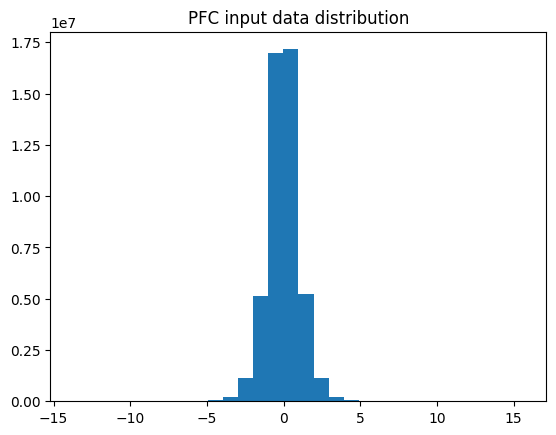

In [15]:
plt.hist(input_data.iloc[:, 4842+10:-11].values.flatten(), bins=30)
plt.title('PFC input data distribution')

Text(0.5, 1.0, 'PFC_from_HC output data distribution')

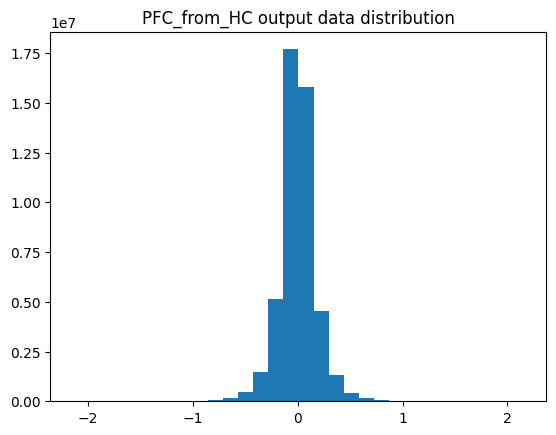

In [16]:
plt.hist(PFC_from_HC.iloc[:, :4850].values.flatten(), bins=30)
plt.title('PFC_from_HC output data distribution')

In [17]:
PFC_from_PFC = pd.read_csv('/home/rachel/Desktop/mm-vae results/multiregion_adbxd_cr/cvae_singlegaussian_30perc/reconPFC_epoch25_vaePFC.csv')
PFC_from_PFC

/tmp/ipykernel_30360/2401954253.py:1: DtypeWarning: Columns (4860) have mixed types. Specify dtype option on import or set low_memory=False.
  PFC_from_PFC = pd.read_csv('/home/rachel/Desktop/mm-vae results/multiregion_adbxd_cr/cvae_singlegaussian_30perc/reconPFC_epoch25_vaePFC.csv')


,0,1,2,3,4,5,6,7,8,9,...,subclass_PFC,cell_type_PFC,SCBID_PFC,MouseID_PFC,Age_PFC,Genotype_PFC,CFM_14_5_snRNA_PFC,14-6-residual_PFC,14-6-Bin_PFC,strain
0,0.027256,0.070743,0.088962,0.146005,-0.179630,-0.279313,0.088849,0.106241,-0.088226,0.303673,...,334 Microglia NN,Immune,CK19032,1596,14,5,59.16,0.738297,3,124
1,-0.010613,0.041053,0.059468,0.108782,-0.132895,-0.194401,0.065312,0.091447,-0.042647,0.239978,...,319 Astro-TE NN,Astrocytes,CK19032,1596,14,5,59.16,0.738297,3,124
2,-0.050440,-0.098677,-0.104008,-0.186723,0.196842,0.273087,-0.088027,-0.114724,0.028393,-0.335561,...,030 L6 CT CTX Glut,Glut,CK19032,1596,14,5,59.16,0.738297,3,124
3,0.080116,-0.069721,-0.209011,-0.358732,0.259967,0.423594,-0.197162,-0.197840,-0.084756,-0.490528,...,007 L2/3 IT CTX Glut,Glut,CK19032,1596,14,5,59.16,0.738297,3,124
4,0.075167,0.033605,0.053804,0.147265,-0.187200,-0.228022,0.065451,0.050222,-0.111522,0.261508,...,327 Oligo NN,Oligo,CK19032,1596,14,5,59.16,0.738297,3,124
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9746,0.097539,0.115466,0.078602,0.195027,-0.266901,-0.365682,0.090252,0.100329,-0.111291,0.421405,...,334 Microglia NN,Immune,CK19090,1490,14,5,39.47,-0.460462,1,28
9747,-0.118362,-0.145627,-0.058712,-0.121777,0.137227,0.137556,-0.077424,-0.116597,0.087995,-0.272995,...,066 NDB-SI-ant Prdm12 Gaba,Gaba,CK19090,1490,14,5,39.47,-0.460462,1,28
9748,0.032269,0.065471,0.055364,0.148002,-0.164531,-0.247923,0.084430,0.072212,-0.075673,0.330562,...,327 Oligo NN,Oligo,CK19090,1490,14,5,39.47,-0.460462,1,28
9749,0.023999,-0.027637,0.028859,0.065206,-0.111662,-0.134927,0.021955,0.022084,0.036156,0.177601,...,010 IT AON-TT-DP Glut,Glut,CK19090,1490,14,5,39.47,-0.460462,1,28


Text(0.5, 1.0, 'PFC_from_PFC output data distribution')

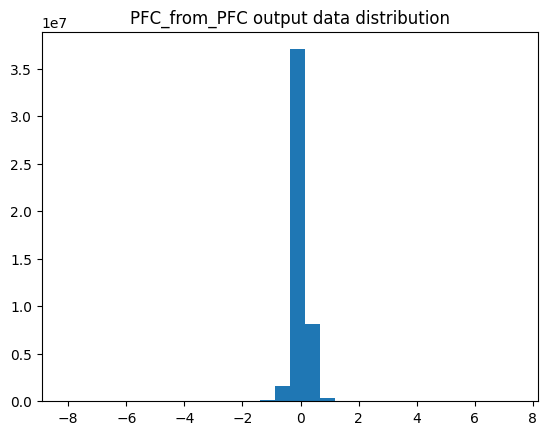

In [18]:
plt.hist(PFC_from_PFC.iloc[:, :4850].values.flatten(), bins=30)
plt.title('PFC_from_PFC output data distribution')

In [20]:
np.max(PFC_from_PFC.iloc[:, :4842]), np.min(PFC_from_PFC.iloc[:, :4842]), np.std(PFC_from_PFC.iloc[:, :4842]).mean(), np.mean(PFC_from_PFC.iloc[:, :4842])

/home/rachel/miniforge3/envs/mm-vae/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3643: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


(7.3909707, -8.137262, 0.18870105030596376, 8.927076991026607e-05)